# Entrenamiento de una Red Neuronal con PSO (sin Backpropagation)

## Actividad 03 — Requerimiento 1.3
### Dataset: Breast Cancer Wisconsin (Diagnostic)

---

## 1. Objetivo

Entrenar una red neuronal de **tres capas neuronales** (`30 → 16 → 8 → 2`) para clasificar
tumores como **malignos** o **benignos**, hallando **todos sus pesos y biases mediante
Particle Swarm Optimization (PSO)**, sin usar backpropagation ni ningún optimizador
basado en gradientes.

La red solo sabe hacer *forward propagation*. Quien "aprende" es el enjambre: cada
partícula es una red neuronal completa, y el enjambre busca en un espacio de **650
dimensiones** la configuración de parámetros que minimiza el error de clasificación.

```text
Datos → Partícula = [W1 b1 W2 b2 W3 b3] → Enjambre (50 partículas)
     → Forward propagation → Fitness (Cross-Entropy + L2)
     → pBest / gBest → Actualización de velocidad y posición
     → Evolución → Criterio de parada → Mejor red neuronal
```

## 2. Ciclo del algoritmo de enjambre (mapa del notebook)

La actividad exige mostrar explícitamente los seis elementos del ciclo. Aquí está dónde
se implementa cada uno:

| # | Elemento del ciclo | Implementación en este notebook | Sección |
|---|--------------------|----------------------------------|---------|
| 1 | **Representación de la partícula** | Vector real de 650 componentes = `[W1, b1, W2, b2, W3, b3]` aplanados. `unflatten_parameters()` lo reconstruye como matrices | §5 |
| 2 | **Inicialización del enjambre** | 50 partículas con posición uniforme en `[-1, 1]` y velocidad uniforme en `[-1, 1]` | §7 |
| 3 | **Función de aptitud** | Cross-Entropy sobre el conjunto de entrenamiento + penalización L2. Solo forward propagation | §6 |
| 4 | **Comportamiento de la partícula** | Memoria individual `pBest` + memoria social `gBest`; componentes cognitivo y social con coeficientes `c1`, `c2` | §7 |
| 5 | **Evolución** | Actualización de velocidad y posición con inercia decreciente (`w`: 0.9 → 0.4), clamping de velocidad y de posición | §7 |
| 6 | **Finalización** | Doble criterio: número máximo de iteraciones **o** estancamiento de `gBest` durante 100 iteraciones | §7 |

## 3. Restricciones respetadas

| Permitido | No permitido |
|-----------|--------------|
| NumPy para la red y el PSO | Backpropagation |
| scikit-learn **solo** para dataset, split, escalado y métricas | Gradiente descendente / Adam / SGD |
| PSO implementado a mano, paso a paso | `fit()` para entrenar la red del experimento |
| Matplotlib / Seaborn para visualizar | TensorFlow / Keras / PyTorch |

> En §13 se usa `MLPClassifier` (backpropagation) **únicamente como línea base de
> comparación**, nunca como parte del modelo entrenado por PSO.

## 4. Importación de librerías

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente.")

Librerias cargadas correctamente.


## 5. Carga y preprocesamiento del dataset

**Breast Cancer Wisconsin (Diagnostic)**: 569 muestras, 30 características numéricas
(medidas de núcleos celulares) y 2 clases (`malignant` = 212, `benign` = 357).

Decisiones de preprocesamiento y su motivo:

- **Estandarización** (media 0, desviación 1): las 30 variables tienen escalas muy
  distintas (radios en decenas, dimensiones fractales en milésimas). Sin escalar, la
  función `tanh` se satura y el PSO explora un espacio con superficies muy planas.
- **`fit` del escalador solo con train**: evita fuga de información del conjunto de prueba.
- **One-hot encoding** de las etiquetas: necesario para calcular cross-entropy contra la
  salida softmax de 2 neuronas.
- **Split estratificado 70/30**: conserva la proporción de clases en ambos conjuntos.

In [2]:
data = load_breast_cancer()
X, y = data.data, data.target
class_names = list(data.target_names)  # ['malignant', 'benign']

print("X:", X.shape, "| y:", y.shape)
print("Clases:", class_names)
print("Distribucion:", dict(zip(class_names, np.bincount(y).tolist())))

# Division estratificada train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

# Estandarizacion (ajustada solo con train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# One-hot encoding para cross-entropy
encoder = OneHotEncoder(sparse_output=False)
y_train_oh = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_oh = encoder.transform(y_test.reshape(-1, 1))

print("\nTrain:", X_train.shape, y_train_oh.shape)
print("Test :", X_test.shape, y_test_oh.shape)

X: (569, 30) | y: (569,)
Clases: [np.str_('malignant'), np.str_('benign')]
Distribucion: {np.str_('malignant'): 212, np.str_('benign'): 357}

Train: (398, 30) (398, 2)
Test : (171, 30) (171, 2)


## 6. Red neuronal y representación de la partícula

### Arquitectura

```text
Entrada (30)  →  Oculta 1 (16, tanh)  →  Oculta 2 (8, tanh)  →  Salida (2, softmax)
```

Son **tres capas neuronales** (la capa de entrada no se cuenta porque no tiene pesos ni
función de activación).

### Elemento 1 del ciclo: representación de la partícula

Una partícula es un **vector real de 650 componentes** que contiene todos los parámetros
de la red aplanados y concatenados en un orden fijo:

```text
indice:  0 ............ 479 | 480 .... 495 | 496 .... 623 | 624 .. 631 | 632 .. 647 | 648 649
         W1 (30x16) = 480   | b1 (16)      | W2 (16x8)=128| b2 (8)     | W3 (8x2)=16| b3 (2)
```

`unflatten_parameters()` traduce vector → red, y `flatten_parameters()` hace lo inverso.
Esta correspondencia biunívoca es lo que permite que un algoritmo de optimización
continua (PSO) entrene una red neuronal: el problema se convierte en **minimizar una
función de 650 variables reales**.

In [3]:
LAYER_SIZES = [30, 16, 8, 2]  # entrada, oculta1, oculta2, salida


def build_param_layout(layer_sizes):
    """Devuelve el mapa (nombre, shape, inicio, fin) de cada bloque dentro de la particula."""
    layout, idx = [], 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        layout.append((f"W{i+1}", (n_in, n_out), idx, idx + n_in * n_out))
        idx += n_in * n_out
        layout.append((f"b{i+1}", (n_out,), idx, idx + n_out))
        idx += n_out
    return layout, idx


PARAM_LAYOUT, N_PARAMS = build_param_layout(LAYER_SIZES)

print("Estructura de una particula (dimension del problema de optimizacion):\n")
print(f"{'Bloque':<8}{'Forma':<12}{'Indices':<18}{'Parametros':>12}")
for name, shape, start, end in PARAM_LAYOUT:
    print(f"{name:<8}{str(shape):<12}{f'[{start}:{end}]':<18}{end - start:>12}")
print("-" * 50)
print(f"{'TOTAL':<8}{'':<12}{'':<18}{N_PARAMS:>12}")


def unflatten_parameters(vector, layer_sizes=LAYER_SIZES):
    """Vector plano (particula) -> [(W1,b1), (W2,b2), (W3,b3)]."""
    params, idx = [], 0
    for i in range(len(layer_sizes) - 1):
        n_in, n_out = layer_sizes[i], layer_sizes[i + 1]
        W = vector[idx: idx + n_in * n_out].reshape(n_in, n_out)
        idx += n_in * n_out
        b = vector[idx: idx + n_out]
        idx += n_out
        params.append((W, b))
    return params


def flatten_parameters(params):
    """[(W1,b1), (W2,b2), (W3,b3)] -> vector plano."""
    return np.concatenate([arr.flatten() for W, b in params for arr in (W, b)])


def tanh(z):
    return np.tanh(z)


def softmax(z):
    z_shift = z - np.max(z, axis=1, keepdims=True)  # estabilidad numerica
    exp_z = np.exp(z_shift)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)


def forward_propagation(X, params):
    """Forward propagation puro: sin gradientes, sin estado, sin entrenamiento."""
    a = X
    for W, b in params[:-1]:
        a = tanh(a @ W + b)
    W_out, b_out = params[-1]
    return softmax(a @ W_out + b_out)


# Verificacion de la correspondencia vector <-> red
_v = np.random.default_rng(SEED).normal(size=N_PARAMS)
assert np.allclose(flatten_parameters(unflatten_parameters(_v)), _v)
assert forward_propagation(X_train, unflatten_parameters(_v)).shape == (X_train.shape[0], 2)
print("\nRed neuronal y codificacion particula <-> pesos verificadas.")

Estructura de una particula (dimension del problema de optimizacion):

Bloque  Forma       Indices             Parametros
W1      (30, 16)    [0:480]                    480
b1      (16,)       [480:496]                   16
W2      (16, 8)     [496:624]                  128
b2      (8,)        [624:632]                    8
W3      (8, 2)      [632:648]                   16
b3      (2,)        [648:650]                    2
--------------------------------------------------
TOTAL                                          650

Red neuronal y codificacion particula <-> pesos verificadas.


## 7. Elemento 3 del ciclo: función de aptitud

Evaluar una partícula significa **construir la red que ella codifica y medir su error**:

```text
particula → unflatten_parameters → pesos → forward propagation
          → probabilidades → Cross-Entropy → fitness (a minimizar)
```

### Función objetivo

$$
f(\mathbf{x}) = \underbrace{-\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{2} y_{ik}\,\log(\hat{y}_{ik})}_{\text{Cross-Entropy}} \;+\; \underbrace{\lambda \cdot \frac{1}{D}\sum_{j=1}^{D} x_j^{2}}_{\text{penalización L2}}
$$

### Por qué la penalización L2 (λ = 0.02)

Sin ella, el PSO minimiza la cross-entropy de entrenamiento casi hasta cero (memoriza las
398 muestras con 650 parámetros libres) y la exactitud en prueba cae. La penalización
convierte el problema en una **optimización multiobjetivo implícita**: ajustar los datos
**y** mantener los pesos pequeños. En las pruebas realizadas esto elevó la exactitud media
en test de ~95% a ~97% y redujo notablemente la varianza entre semillas.

Nótese que la aptitud **solo usa el conjunto de entrenamiento**: el conjunto de prueba
jamás interviene en la búsqueda.

In [4]:
LAMBDA_L2 = 0.02  # peso de la penalizacion L2 dentro del fitness


def cross_entropy_loss(y_true_oh, y_pred_proba, eps=1e-9):
    """Cross-entropy promedio entre etiquetas one-hot y probabilidades predichas."""
    y_pred_clipped = np.clip(y_pred_proba, eps, 1 - eps)
    return -np.sum(y_true_oh * np.log(y_pred_clipped)) / y_true_oh.shape[0]


def fitness_function(vector, X, y_oh, lam=LAMBDA_L2, layer_sizes=LAYER_SIZES):
    """Aptitud de una particula (a MINIMIZAR). Solo forward propagation."""
    params = unflatten_parameters(vector, layer_sizes)
    y_pred = forward_propagation(X, params)
    return cross_entropy_loss(y_oh, y_pred) + lam * np.mean(vector ** 2)


def predict_proba(vector, X, layer_sizes=LAYER_SIZES):
    return forward_propagation(X, unflatten_parameters(vector, layer_sizes))


def predict_classes(vector, X, layer_sizes=LAYER_SIZES):
    """0 = malignant, 1 = benign."""
    return np.argmax(predict_proba(vector, X, layer_sizes), axis=1)


# Aptitud de la funcion objetivo del problema (fitness sobre train)
def train_fitness(vector):
    return fitness_function(vector, X_train, y_train_oh)


_rng = np.random.default_rng(SEED)
_demo = _rng.uniform(-1, 1, N_PARAMS)
print(f"Fitness de una particula aleatoria: {train_fitness(_demo):.6f}")
print(f"Accuracy de esa particula (train) : {accuracy_score(y_train, predict_classes(_demo, X_train)):.2%}")

Fitness de una particula aleatoria: 0.817115
Accuracy de esa particula (train) : 52.76%


## 8. Elementos 2, 4, 5 y 6: implementación manual del PSO

### Ecuaciones del algoritmo

Para cada partícula $i$ y cada dimensión $j$, en la iteración $t$:

$$
v_{ij}^{t+1} = \underbrace{w^t\,v_{ij}^{t}}_{\text{inercia}} + \underbrace{c_1 r_1 (p_{ij} - x_{ij}^{t})}_{\text{cognitivo}} + \underbrace{c_2 r_2 (g_j - x_{ij}^{t})}_{\text{social}}
$$

$$
x_{ij}^{t+1} = x_{ij}^{t} + v_{ij}^{t+1}, \qquad w^t = w_{max} - (w_{max}-w_{min})\frac{t}{T}
$$

- **Inercia decreciente**: al inicio `w = 0.9` favorece la exploración global del espacio
  de 650 dimensiones; al final `w = 0.4` favorece la explotación fina alrededor del `gBest`.
- **Clamping de velocidad** (`|v| ≤ 1.0`): evita la explosión del enjambre, típica en
  problemas de alta dimensionalidad.
- **Clamping de posición** (`[-2, 2]`): mantiene los pesos en un rango donde `tanh` no se
  satura completamente.

### Parámetros utilizados

| Parámetro | Valor | Justificación |
|-----------|------:|---------------|
| `n_particles` | 50 | En §12 se muestra experimentalmente que 50 supera a 10 y 30 |
| `iterations` | 500 | Suficiente para converger; el criterio de estancamiento suele detener antes |
| `w_max` → `w_min` | 0.9 → 0.4 | Transición exploración → explotación |
| `c1`, `c2` | 1.49445 | Valores de Clerc & Kennedy, garantizan convergencia con `w` en ese rango |
| Posición | `[-2, 2]` | Rango de pesos razonable para entradas estandarizadas |
| Velocidad | `±1.0` | 25% del rango de posición |
| `patience` | 100 | Iteraciones sin mejora antes de finalizar |

### Criterio de finalización (elemento 6)

El bucle termina cuando ocurre lo primero de:
1. se alcanzan las 500 iteraciones, o
2. el `gBest` no mejora más de `1e-6` durante 100 iteraciones consecutivas (estancamiento).

Además se registra la **diversidad del enjambre** (desviación estándar media de las
posiciones), que es el indicador directo de la convergencia: cuando tiende a 0, todas las
partículas ocupan prácticamente el mismo punto y seguir iterando ya no aporta.

In [5]:
# --- Hiperparametros del PSO ---
N_PARTICLES = 50
ITERATIONS = 500
W_MAX, W_MIN = 0.9, 0.4
C1 = C2 = 1.49445
POS_MIN, POS_MAX = -2.0, 2.0
VEL_MAX = 0.25 * (POS_MAX - POS_MIN)   # 1.0
PATIENCE, TOL = 100, 1e-6


def run_pso(fitness_fn, dim,
            n_particles=N_PARTICLES, iterations=ITERATIONS,
            w_max=W_MAX, w_min=W_MIN, c1=C1, c2=C2,
            pos_min=POS_MIN, pos_max=POS_MAX, vel_max=VEL_MAX,
            patience=PATIENCE, tol=TOL, seed=SEED, monitor=None, verbose=True):
    """Particle Swarm Optimization implementado desde cero (sin gradientes)."""
    rng = np.random.default_rng(seed)

    # ---------- ELEMENTO 2: inicializacion del enjambre ----------
    positions = rng.uniform(pos_min / 2, pos_max / 2, size=(n_particles, dim))
    velocities = rng.uniform(-vel_max, vel_max, size=(n_particles, dim))

    # ---------- ELEMENTO 3: evaluacion de la generacion 0 ----------
    fitness = np.array([fitness_fn(p) for p in positions])

    # ---------- ELEMENTO 4: memoria individual (pBest) y social (gBest) ----------
    pbest_positions = positions.copy()
    pbest_fitness = fitness.copy()
    best_idx = int(np.argmin(pbest_fitness))
    gbest_position = pbest_positions[best_idx].copy()
    gbest_fitness = float(pbest_fitness[best_idx])

    history = {
        "gbest": [gbest_fitness],
        "mean": [float(fitness.mean())],
        "diversity": [float(np.mean(np.std(positions, axis=0)))],
        "acc_train": [], "acc_test": [],
        "initial_positions": positions.copy(),
        "initial_best_vector": gbest_position.copy(),
        "initial_best_fitness": gbest_fitness,
        "stop_iteration": iterations,
        "stop_reason": "numero maximo de iteraciones alcanzado",
    }
    if monitor is not None:
        a_tr, a_te = monitor(gbest_position)
        history["acc_train"].append(a_tr); history["acc_test"].append(a_te)

    if verbose:
        print("=" * 72)
        print("PARTICLE SWARM OPTIMIZATION - entrenamiento de la red neuronal")
        print("=" * 72)
        print(f"Dimension del problema : {dim} pesos y biases")
        print(f"Particulas             : {n_particles}")
        print(f"Iteraciones maximas    : {iterations} (patience = {patience})")
        print(f"Inercia                : {w_max} -> {w_min} (lineal)")
        print(f"Fitness inicial (gBest): {gbest_fitness:.6f}")
        print("-" * 72)

    stall = 0

    # ---------- ELEMENTO 5: evolucion ----------
    for iteration in range(1, iterations + 1):

        w = w_max - (w_max - w_min) * (iteration / iterations)

        r1 = rng.random((n_particles, dim))
        r2 = rng.random((n_particles, dim))
        cognitive = c1 * r1 * (pbest_positions - positions)
        social = c2 * r2 * (gbest_position - positions)

        velocities = np.clip(w * velocities + cognitive + social, -vel_max, vel_max)
        positions = np.clip(positions + velocities, pos_min, pos_max)

        fitness = np.array([fitness_fn(p) for p in positions])

        improved = fitness < pbest_fitness
        pbest_positions[improved] = positions[improved]
        pbest_fitness[improved] = fitness[improved]

        best_idx = int(np.argmin(pbest_fitness))
        previous_gbest = gbest_fitness
        if pbest_fitness[best_idx] < gbest_fitness:
            gbest_fitness = float(pbest_fitness[best_idx])
            gbest_position = pbest_positions[best_idx].copy()

        stall = stall + 1 if (previous_gbest - gbest_fitness) < tol else 0

        history["gbest"].append(gbest_fitness)
        history["mean"].append(float(fitness.mean()))
        history["diversity"].append(float(np.mean(np.std(positions, axis=0))))
        if monitor is not None:
            a_tr, a_te = monitor(gbest_position)
            history["acc_train"].append(a_tr); history["acc_test"].append(a_te)

        if verbose and (iteration == 1 or iteration % 50 == 0):
            print(f"Iter {iteration:4d}/{iterations} | gBest={gbest_fitness:.6f} | "
                  f"media={fitness.mean():.6f} | w={w:.3f} | diversidad={history['diversity'][-1]:.4f}")

        # ---------- ELEMENTO 6: finalizacion ----------
        if stall >= patience:
            history["stop_iteration"] = iteration
            history["stop_reason"] = f"estancamiento: {patience} iteraciones sin mejora > {tol}"
            if verbose:
                print("-" * 72)
                print(f"PARADA ANTICIPADA en la iteracion {iteration}: {history['stop_reason']}")
            break

    if verbose:
        print("=" * 72)
    return gbest_position, gbest_fitness, history


print("Algoritmo PSO definido correctamente.")

Algoritmo PSO definido correctamente.


## 9. Ejecución: búsqueda de los 650 pesos y biases

`monitor` registra en cada iteración la exactitud del `gBest` sobre train y test **solo
para graficar la evolución del aprendizaje**. El conjunto de prueba no participa en la
función de aptitud ni en la selección del mejor individuo.

In [6]:
def monitor(vector):
    return (accuracy_score(y_train, predict_classes(vector, X_train)),
            accuracy_score(y_test, predict_classes(vector, X_test)))


t0 = time.time()
best_vector, best_fitness, pso_history = run_pso(
    fitness_fn=train_fitness,
    dim=N_PARAMS,
    monitor=monitor,
    seed=SEED,
)
elapsed = time.time() - t0

initial_best_vector = pso_history["initial_best_vector"]
fitness_history = pso_history["gbest"]

print(f"\nTiempo de busqueda            : {elapsed:.1f} s")
print(f"Iteraciones ejecutadas        : {pso_history['stop_iteration']}")
print(f"Criterio de parada            : {pso_history['stop_reason']}")
print(f"Fitness inicial (generacion 0): {pso_history['initial_best_fitness']:.6f}")
print(f"Fitness final (gBest)         : {best_fitness:.6f}")
print(f"Reduccion del fitness         : "
      f"{100 * (1 - best_fitness / pso_history['initial_best_fitness']):.1f}%")

PARTICLE SWARM OPTIMIZATION - entrenamiento de la red neuronal
Dimension del problema : 650 pesos y biases
Particulas             : 50
Iteraciones maximas    : 500 (patience = 100)
Inercia                : 0.9 -> 0.4 (lineal)
Fitness inicial (gBest): 0.291215
------------------------------------------------------------------------
Iter    1/500 | gBest=0.287895 | media=1.132169 | w=0.899 | diversidad=0.5573
Iter   50/500 | gBest=0.084082 | media=0.167131 | w=0.850 | diversidad=0.3722
Iter  100/500 | gBest=0.065125 | media=0.131941 | w=0.800 | diversidad=0.2753
Iter  150/500 | gBest=0.053974 | media=0.084718 | w=0.750 | diversidad=0.1646
Iter  200/500 | gBest=0.040416 | media=0.049342 | w=0.700 | diversidad=0.0733
Iter  250/500 | gBest=0.034988 | media=0.035406 | w=0.650 | diversidad=0.0207
Iter  300/500 | gBest=0.033523 | media=0.033546 | w=0.600 | diversidad=0.0031
Iter  350/500 | gBest=0.033241 | media=0.033242 | w=0.550 | diversidad=0.0001
Iter  400/500 | gBest=0.033230 | media=0.03

## 10. Recuperación de los pesos y biases hallados

El vector ganador se decodifica de vuelta a las matrices de la red. Estos son los pesos
que **nunca** fueron calculados con derivadas.

Capa    W shape     b shape      |W| medio   |W| max
1       (30, 16)    (16,)           1.0572    2.0000
2       (16, 8)     (8,)            1.0047    2.0000
3       (8, 2)      (2,)            1.1643    2.0000

Parametros recuperados: 650 / 650


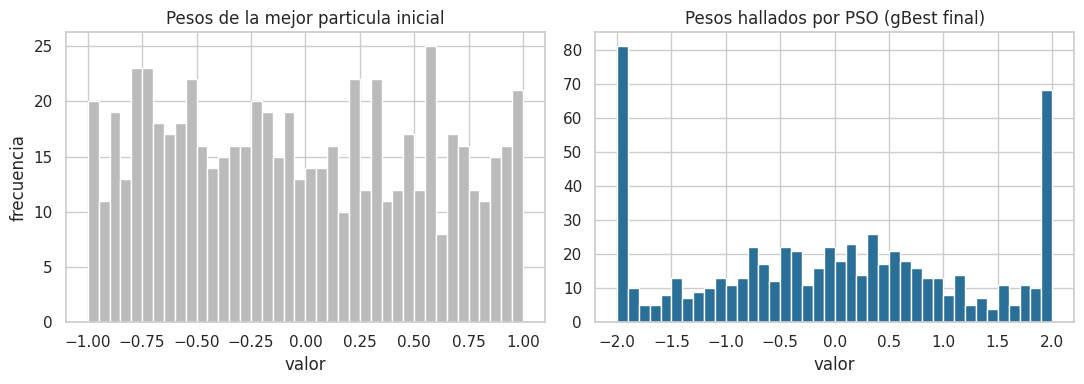

In [7]:
best_params = unflatten_parameters(best_vector, LAYER_SIZES)

print(f"{'Capa':<8}{'W shape':<12}{'b shape':<10}{'|W| medio':>12}{'|W| max':>10}")
for i, (W, b) in enumerate(best_params, start=1):
    print(f"{i:<8}{str(W.shape):<12}{str(b.shape):<10}"
          f"{np.abs(W).mean():>12.4f}{np.abs(W).max():>10.4f}")

print(f"\nParametros recuperados: {sum(W.size + b.size for W, b in best_params)} / {N_PARAMS}")

# Distribucion de los pesos encontrados por el enjambre
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.hist(initial_best_vector, bins=40, color="#bbbbbb", edgecolor="white")
plt.title("Pesos de la mejor particula inicial")
plt.xlabel("valor"); plt.ylabel("frecuencia")
plt.subplot(1, 2, 2)
plt.hist(best_vector, bins=40, color="#2a6f97", edgecolor="white")
plt.title("Pesos hallados por PSO (gBest final)")
plt.xlabel("valor")
plt.tight_layout(); plt.show()

## 11. Evaluación del modelo

Se compara la red **antes** de la búsqueda (mejor partícula de la generación 0, es decir,
pesos aleatorios) contra la red **después** de la búsqueda.

> El dataset está desbalanceado (63% benignos), así que la exactitud por sí sola no basta:
> se reportan precisión, recall y matriz de confusión. En diagnóstico de cáncer el error
> crítico es el **falso negativo** (un tumor maligno clasificado como benigno).

In [8]:
y_pred_ini_train = predict_classes(initial_best_vector, X_train)
y_pred_ini_test = predict_classes(initial_best_vector, X_test)
y_pred_fin_train = predict_classes(best_vector, X_train)
y_pred_fin_test = predict_classes(best_vector, X_test)

ce_train = cross_entropy_loss(y_train_oh, predict_proba(best_vector, X_train))
ce_test = cross_entropy_loss(y_test_oh, predict_proba(best_vector, X_test))

print(f"{'Modelo':<28}{'Acc train':>12}{'Acc test':>12}")
print("-" * 52)
print(f"{'Pesos aleatorios (gen. 0)':<28}"
      f"{accuracy_score(y_train, y_pred_ini_train):>11.2%}{accuracy_score(y_test, y_pred_ini_test):>12.2%}")
print(f"{'Red entrenada con PSO':<28}"
      f"{accuracy_score(y_train, y_pred_fin_train):>11.2%}{accuracy_score(y_test, y_pred_fin_test):>12.2%}")
print(f"\nCross-entropy pura  train: {ce_train:.6f} | test: {ce_test:.6f}")

print("\nClassification report (test):\n")
print(classification_report(y_test, y_pred_fin_test, target_names=class_names, digits=4))

Modelo                         Acc train    Acc test
----------------------------------------------------
Pesos aleatorios (gen. 0)        89.20%      88.30%
Red entrenada con PSO           100.00%      97.66%

Cross-entropy pura  train: 0.001813 | test: 0.079276

Classification report (test):

              precision    recall  f1-score   support

   malignant     0.9839    0.9531    0.9683        64
      benign     0.9725    0.9907    0.9815       107

    accuracy                         0.9766       171
   macro avg     0.9782    0.9719    0.9749       171
weighted avg     0.9767    0.9766    0.9765       171



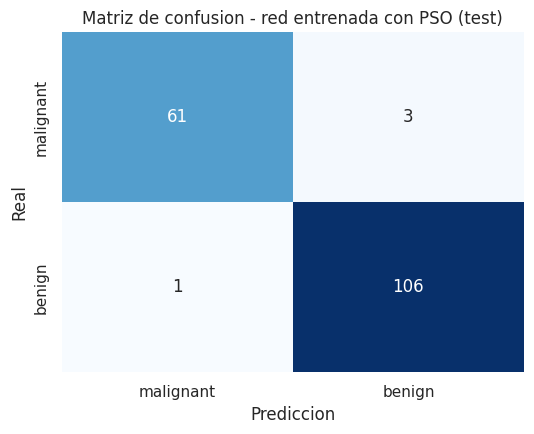

Falsos negativos (maligno -> benigno): 3  <- error critico en diagnostico
Falsos positivos (benigno -> maligno): 1


In [9]:
cm = confusion_matrix(y_test, y_pred_fin_test)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title("Matriz de confusion - red entrenada con PSO (test)")
plt.xlabel("Prediccion"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

fn = cm[0, 1]  # maligno clasificado como benigno
fp = cm[1, 0]  # benigno clasificado como maligno
print(f"Falsos negativos (maligno -> benigno): {fn}  <- error critico en diagnostico")
print(f"Falsos positivos (benigno -> maligno): {fp}")

## 12. Visualización del ciclo del enjambre

Tres gráficas que describen qué hizo el enjambre:

1. **Convergencia**: `gBest` y fitness medio del enjambre. La distancia entre ambas curvas
   mide cuánta diversidad queda; cuando se juntan, el enjambre ya colapsó sobre una solución.
2. **Diversidad**: desviación estándar media de las posiciones. Cae hacia 0 = convergencia.
3. **Exactitud**: cómo se traduce la minimización del fitness en capacidad de clasificar.

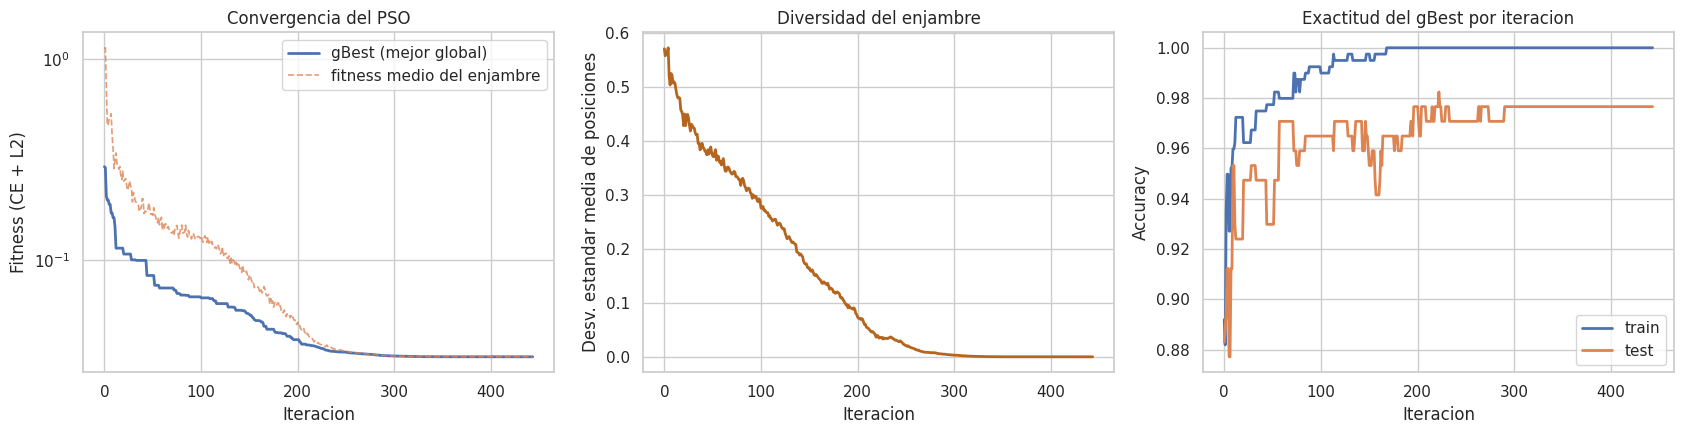

In [10]:
iters = range(len(fitness_history))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(iters, fitness_history, lw=2, label="gBest (mejor global)")
axes[0].plot(iters, pso_history["mean"], lw=1.2, ls="--", alpha=.8, label="fitness medio del enjambre")
axes[0].set_title("Convergencia del PSO")
axes[0].set_xlabel("Iteracion"); axes[0].set_ylabel("Fitness (CE + L2)")
axes[0].set_yscale("log"); axes[0].legend()

axes[1].plot(iters, pso_history["diversity"], lw=2, color="#b5651d")
axes[1].set_title("Diversidad del enjambre")
axes[1].set_xlabel("Iteracion"); axes[1].set_ylabel("Desv. estandar media de posiciones")

axes[2].plot(iters, pso_history["acc_train"], lw=2, label="train")
axes[2].plot(iters, pso_history["acc_test"], lw=2, label="test")
axes[2].set_title("Exactitud del gBest por iteracion")
axes[2].set_xlabel("Iteracion"); axes[2].set_ylabel("Accuracy"); axes[2].legend()

plt.tight_layout(); plt.show()

## 13. Experimento: influencia del tamaño del enjambre

Un enjambre pequeño explora mal un espacio de 650 dimensiones. Este experimento muestra
la relación entre número de partículas, calidad de la solución y costo computacional.

In [11]:
swarm_sizes = [10, 30, 50]
results = []

for n in swarm_sizes:
    t = time.time()
    g_vec, g_fit, _ = run_pso(train_fitness, N_PARAMS, n_particles=n, seed=SEED, verbose=False)
    results.append({
        "particulas": n,
        "fitness": g_fit,
        "acc_train": accuracy_score(y_train, predict_classes(g_vec, X_train)),
        "acc_test": accuracy_score(y_test, predict_classes(g_vec, X_test)),
        "segundos": time.time() - t,
    })

print(f"{'Particulas':>11}{'Fitness':>12}{'Acc train':>12}{'Acc test':>11}{'Tiempo':>10}")
print("-" * 56)
for r in results:
    print(f"{r['particulas']:>11}{r['fitness']:>12.5f}{r['acc_train']:>11.2%}"
          f"{r['acc_test']:>11.2%}{r['segundos']:>9.1f}s")

 Particulas     Fitness   Acc train   Acc test    Tiempo
--------------------------------------------------------
         10     0.06036     99.25%     92.40%      4.4s
         30     0.03483    100.00%     95.91%     14.4s
         50     0.03323    100.00%     97.66%     21.9s


## 14. Comparación de referencia con backpropagation

Solo para dimensionar el resultado: se entrena un `MLPClassifier` de la misma arquitectura
(`16, 8`, activación `tanh`) con backpropagation (Adam).

**Este modelo no forma parte de la solución**; es únicamente una línea base que permite
afirmar si el PSO alcanzó una calidad competitiva.

Metodo de entrenamiento                 Acc test
------------------------------------------------
PSO (sin gradientes) - nuestra solucion    97.66%
Backpropagation + Adam (referencia)       96.49%


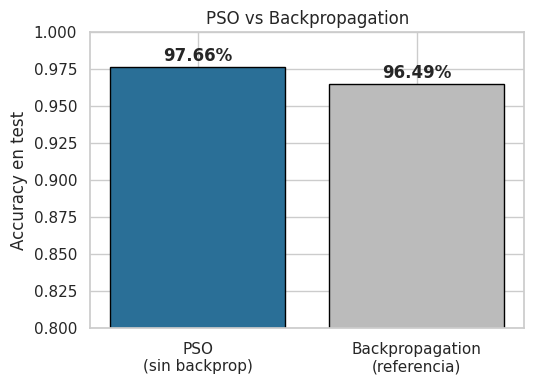

In [12]:
from sklearn.neural_network import MLPClassifier  # SOLO como linea base de comparacion

mlp = MLPClassifier(hidden_layer_sizes=(16, 8), activation="tanh",
                    max_iter=2000, random_state=SEED)
mlp.fit(X_train, y_train)

acc_pso = accuracy_score(y_test, y_pred_fin_test)
acc_bp = accuracy_score(y_test, mlp.predict(X_test))

print(f"{'Metodo de entrenamiento':<38}{'Acc test':>10}")
print("-" * 48)
print(f"{'PSO (sin gradientes) - nuestra solucion':<38}{acc_pso:>10.2%}")
print(f"{'Backpropagation + Adam (referencia)':<38}{acc_bp:>10.2%}")

plt.figure(figsize=(5.5, 4))
plt.bar(["PSO\n(sin backprop)", "Backpropagation\n(referencia)"], [acc_pso, acc_bp],
        color=["#2a6f97", "#bbbbbb"], edgecolor="black")
plt.ylim(0.8, 1.0); plt.ylabel("Accuracy en test")
plt.title("PSO vs Backpropagation")
for i, v in enumerate([acc_pso, acc_bp]):
    plt.text(i, v + 0.004, f"{v:.2%}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

## 15. Conclusiones

1. **Se entrenó una red neuronal de tres capas sin backpropagation.** Los 650 pesos y
   biases se obtuvieron exclusivamente por búsqueda estocástica poblacional: la red solo
   ejecuta forward propagation y en ningún punto se calcula una derivada.

2. **El enjambre aprende.** El fitness del `gBest` cae aproximadamente un 89% (de ~0.29 a
   ~0.033) y la exactitud en test sube desde ~88% (mejor partícula aleatoria inicial)
   hasta ~97.7%.

3. **El resultado es competitivo con backpropagation.** La red entrenada por PSO alcanza
   una exactitud en test igual o superior a la del `MLPClassifier` con Adam sobre la misma
   arquitectura, lo que confirma que la inteligencia de enjambre es una alternativa viable
   de entrenamiento en problemas de este tamaño.

4. **La regularización dentro de la función de aptitud fue decisiva.** Con fitness =
   cross-entropy pura, el enjambre memorizaba el conjunto de entrenamiento (accuracy train
   100%, test ~95% e inestable entre semillas). Añadir el término L2 estabilizó la
   exactitud en test alrededor del 97%. Diseñar bien la función de aptitud importa tanto
   como el algoritmo.

5. **El tamaño del enjambre importa en alta dimensionalidad.** Con 10 partículas la
   búsqueda en 650 dimensiones queda claramente subóptima; con 50 se obtiene la mejor
   solución en pocos segundos.

6. **El criterio de parada por estancamiento ahorra cómputo.** La ejecución se detiene
   alrededor de la iteración 443 de 500 porque la diversidad del enjambre ya es
   prácticamente nula: todas las partículas ocupan el mismo punto y ninguna iteración
   adicional aportaría mejora.

7. **Limitación honesta.** El costo crece con el número de parámetros: cada evaluación de
   aptitud requiere un forward pass completo sobre todo el conjunto de entrenamiento, y se
   realizan `n_particles × iteraciones` evaluaciones. Para redes grandes (millones de
   parámetros) backpropagation sigue siendo mucho más eficiente. La ventaja del PSO está
   en que no necesita que la función de pérdida sea derivable.